# Avance 4: Modelos Alternativos — ML Recursivo para Predicción de Sarampión
## Proyecto Integrador - Equipo 16

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

### Objetivo

Construir y evaluar **modelos individuales de Machine Learning** con enfoque **recursivo** (multi-step) para predecir el número de casos de sarampión en México a horizontes de 1, 2 y 3 meses.

### Enfoque Recursivo

A diferencia del enfoque *direct* (un modelo independiente por horizonte), el **enfoque recursivo** entrena un único modelo para predecir 1 paso adelante ($t+1$) y luego retroalimenta su propia predicción como feature de entrada para predecir pasos subsecuentes ($t+2$, $t+3$, ...).

### Algoritmos evaluados

| # | Modelo | Tipo | Fortaleza |
|---|--------|------|----------|
| 1 | **XGBoost** | Gradient Boosting | Alta capacidad predictiva; regularización L1/L2 |
| 2 | **LightGBM** | Gradient Boosting | Eficiente en memoria; crecimiento leaf-wise |
| 3 | **Random Forest** | Bagging | Robusto ante sobreajuste; paralelizable |

### Variables exógenas adicionales
1. **Isolation Forest Score** — indicador multivariante de anomalía.
2. **Bayesian Hierarchical Score** — probabilidad anómala vía distribución predictiva Poisson-Gamma.
3. **Dosis de vacunación con desplazamiento** — efecto retardado de la vacunación.

## 1. Configuración e Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from copy import deepcopy

from scipy.stats import nbinom as nbinom_dist
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.seterr(divide="ignore", invalid="ignore")


def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error (0-100%)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # Evitar 0/0: si ambos son 0, el error es 0
    mask = denom > 0
    err = np.zeros_like(y_true)
    err[mask] = np.abs(y_true[mask] - y_pred[mask]) / denom[mask]
    return float(np.mean(err) * 100)


print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga de Datos

In [2]:
# ---------- Carga de datos ----------
base_path = Path("../../..") / "data" / "processed"

# Dataset base: casos de sarampión y dosis de vacunación mensuales (2010-2023)
df = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df["fecha"] = pd.to_datetime(
    df["anio"].astype(str) + "-" + df["mes"].astype(str) + "-01"
)
df = df.sort_values("fecha").reset_index(drop=True)

# Variable objetivo binaria (auxiliar)
df["brote"] = (df["casos_sarampion"] > 0).astype(int)

print(f"Dataset cargado: {df.shape}  ({df['fecha'].min().date()} → {df['fecha'].max().date()})")
print(f"Columnas: {list(df.columns)}")
print(f"\nMeses con brote: {df['brote'].sum()} / {len(df)} ({df['brote'].mean():.1%})")
print(f"Años con al menos un brote: {sorted(df.loc[df['brote']==1, 'anio'].unique())}")

Dataset cargado: (168, 6)  (2010-01-01 → 2023-12-01)
Columnas: ['mes', 'anio', 'total_dosis', 'casos_sarampion', 'fecha', 'brote']

Meses con brote: 17 / 168 (10.1%)
Años con al menos un brote: [2010, 2013, 2018, 2019, 2020]


## 3. Construcción de Variables Exógenas (Scores de Anomalía)

Para enriquecer las features del modelo predictivo, se reutilizan los detectores de anomalías del Avance 3 como **features continuas**:

### 3.1 Isolation Forest Score

Se construyen features temporales básicas (lags, rolling stats de casos y dosis) y se entrena un Isolation Forest **solo sobre datos de entrenamiento** (< 2019) para evitar data leakage. El score de anomalía se usa como feature (mayor valor = más anómalo).

### 3.2 Bayesian Hierarchical Score

Se computa el score bayesiano usando la posterior predictiva Poisson-Gamma calibrada con datos de entrenamiento. El score $= 1 - p\text{-value}$ indica la probabilidad de que la observación sea anómala.

In [3]:
# ============================================================
# 3.1 ISOLATION FOREST SCORE
# ============================================================
SPLIT_YEAR = 2019

# Construir features temporales para el Isolation Forest
# (lags y rolling stats de casos y dosis, calculados sobre todo el df)
df_if = df.copy()
for lag in [1, 2, 3, 6, 12]:
    df_if[f"if_casos_lag_{lag}"] = df_if["casos_sarampion"].shift(lag)
    df_if[f"if_dosis_lag_{lag}"] = df_if["total_dosis"].shift(lag)
df_if["if_rolling_mean_3m"] = df_if["casos_sarampion"].shift(1).rolling(3, min_periods=1).mean()
df_if["if_rolling_std_3m"] = df_if["casos_sarampion"].shift(1).rolling(3, min_periods=1).std().fillna(0)
df_if["if_rolling_mean_6m"] = df_if["casos_sarampion"].shift(1).rolling(6, min_periods=1).mean()
df_if["if_dosis_rolling_3m"] = df_if["total_dosis"].shift(1).rolling(3, min_periods=1).mean()
df_if.dropna(inplace=True)

if_feature_cols = [c for c in df_if.columns if c.startswith("if_")]

# Entrenar solo con datos < 2019
train_mask_if = df_if["anio"] < SPLIT_YEAR
X_train_if = df_if.loc[train_mask_if, if_feature_cols].values
cont_rate = max(df_if.loc[train_mask_if, "brote"].mean(), 0.01)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=cont_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_if)

# Score: mayor = más anómalo (negamos el decision_function)
if_scores = -iso_forest.decision_function(df_if[if_feature_cols].values)

# Mapear scores de vuelta al df original por fecha
df_if["isolation_forest_score"] = if_scores
df = df.merge(
    df_if[["fecha", "isolation_forest_score"]],
    on="fecha", how="left"
)

print(f"Isolation Forest entrenado con {X_train_if.shape[0]} muestras")
print(f"  Features de entrada: {len(if_feature_cols)} ({if_feature_cols})")
print(f"  Contamination rate: {cont_rate:.4f}")
print(f"  Score range: [{df['isolation_forest_score'].min():.4f}, {df['isolation_forest_score'].max():.4f}]")

# ============================================================
# 3.2 BAYESIAN HIERARCHICAL SCORE (Poisson-Gamma)
# ============================================================

def calcular_bayesian_score(df_ref, split_year=2019):
    """Calcula score bayesiano con posterior predictiva Poisson-Gamma."""
    train_data = df_ref[df_ref["anio"] < split_year]

    global_mean = train_data["casos_sarampion"].mean()
    global_var = train_data["casos_sarampion"].var()

    if global_var > global_mean and global_mean > 0:
        beta_0 = global_mean / max(global_var, 1e-6)
        alpha_0 = global_mean * beta_0
    else:
        alpha_0, beta_0 = 0.5, 0.5

    posteriors = {}
    for mes in range(1, 13):
        month_data = train_data[train_data["mes"] == mes]["casos_sarampion"]
        n_m = len(month_data)
        sum_ym = int(month_data.sum())
        posteriors[mes] = (alpha_0 + sum_ym, beta_0 + n_m)

    pvalues = np.zeros(len(df_ref))
    for idx in range(len(df_ref)):
        mes = int(df_ref.iloc[idx]["mes"])
        y_obs = int(df_ref.iloc[idx]["casos_sarampion"])
        alpha_post, beta_post = posteriors[mes]
        r = alpha_post
        p = beta_post / (1.0 + beta_post)
        pvalues[idx] = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p) if y_obs > 0 else 1.0

    return 1.0 - pvalues  # Score: mayor = más anómalo


df["bayesian_score"] = calcular_bayesian_score(df, split_year=SPLIT_YEAR)

print(f"\nBayesian Score calculado")
print(f"  Score range: [{df['bayesian_score'].min():.4f}, {df['bayesian_score'].max():.4f}]")
print(f"  Meses con score > 0.95: {(df['bayesian_score'] > 0.95).sum()}")

Isolation Forest entrenado con 96 muestras
  Features de entrada: 14 (['if_casos_lag_1', 'if_dosis_lag_1', 'if_casos_lag_2', 'if_dosis_lag_2', 'if_casos_lag_3', 'if_dosis_lag_3', 'if_casos_lag_6', 'if_dosis_lag_6', 'if_casos_lag_12', 'if_dosis_lag_12', 'if_rolling_mean_3m', 'if_rolling_std_3m', 'if_rolling_mean_6m', 'if_dosis_rolling_3m'])
  Contamination rate: 0.0312
  Score range: [-0.3272, 0.1441]

Bayesian Score calculado
  Score range: [0.0000, 1.0000]
  Meses con score > 0.95: 12


## 4. Integración de Vacunas con Desplazamiento

Se integra la información de dosis de vacunación con un **desplazamiento temporal** configurable. Esto captura el efecto retardado de la vacunación sobre la incidencia de sarampión: las dosis aplicadas hace N meses son las que protegen hoy.

In [4]:
MESES_DESFASE = 2  # Editable: 1, 2, 3 meses, etc.

# Crear dosis con desplazamiento: total_dosis de hace N meses
col_dosis_lag = f"total_dosis_lag_{MESES_DESFASE}m"
df[col_dosis_lag] = df["total_dosis"].shift(MESES_DESFASE)

# Eliminar filas sin dato de vacunación desplazada
df_model = df.dropna(subset=[col_dosis_lag]).copy().reset_index(drop=True)

print(f"Dataset para modelado: {df_model.shape}")
print(f"Período: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}")
print(f"Desfase de vacunación: {MESES_DESFASE} meses")
print(f"\nColumnas disponibles ({len(df_model.columns)}):")
print(list(df_model.columns))

Dataset para modelado: (166, 9)
Período: 2010-03-01 → 2023-12-01
Desfase de vacunación: 2 meses

Columnas disponibles (9):
['mes', 'anio', 'total_dosis', 'casos_sarampion', 'fecha', 'brote', 'isolation_forest_score', 'bayesian_score', 'total_dosis_lag_2m']


## 5. Preparación de Features para Enfoque Recursivo

En el enfoque recursivo, el modelo predice 1 paso adelante y retroalimenta la predicción. Para esto necesitamos identificar qué features **dependen del target** (y deben actualizarse recursivamente) y cuáles son **exógenas** (no cambian).

### Features que se actualizan recursivamente:
- Lags del target: `casos_lag_1m`, `casos_lag_2m`, `casos_lag_3m`, etc.
- Medias móviles de casos: `casos_rolling_mean_3m_rec`, `casos_rolling_mean_6m_rec`

### Features exógenas (no se actualizan):
- Scores de anomalía (Isolation Forest, Bayesian)
- Dosis de vacunación con desplazamiento
- Features estacionales cíclicas (sin/cos del mes)
- Dosis totales de vacunación

In [5]:
# ============================================================
# 5. CONSTRUCCIÓN DE LAGS Y FEATURES RECURSIVAS
# ============================================================

TARGET = "casos_sarampion"

# Crear lags del target para el enfoque recursivo
for lag in [1, 2, 3, 6, 12]:
    df_model[f"casos_lag_{lag}m"] = df_model[TARGET].shift(lag)

# Media móvil de 3 y 6 meses de casos (serán actualizadas recursivamente)
df_model["casos_rolling_mean_3m_rec"] = (
    df_model[TARGET].shift(1).rolling(3, min_periods=1).mean()
)
df_model["casos_rolling_mean_6m_rec"] = (
    df_model[TARGET].shift(1).rolling(6, min_periods=1).mean()
)

# Features estacionales cíclicas
df_model["mes_sin"] = np.sin(2 * np.pi * df_model["mes"] / 12)
df_model["mes_cos"] = np.cos(2 * np.pi * df_model["mes"] / 12)

# Eliminar filas con NaN por lags
df_model.dropna(inplace=True)
df_model = df_model.reset_index(drop=True)

print(f"Dataset después de crear lags y eliminar NaN: {df_model.shape}")
print(f"Período: {df_model['fecha'].min().date()} → {df_model['fecha'].max().date()}")

# ---------- Definir features del modelo ----------
cols_to_exclude = {"fecha", "anio", "mes", TARGET, "brote"}
model_features = [c for c in df_model.columns if c not in cols_to_exclude]

# Features que dependen del target (se actualizan recursivamente)
recursive_features = [
    "casos_lag_1m", "casos_lag_2m", "casos_lag_3m",
    "casos_lag_6m", "casos_lag_12m",
    "casos_rolling_mean_3m_rec", "casos_rolling_mean_6m_rec",
]

# Features exógenas (no se actualizan con predicciones)
exogenous_features = [f for f in model_features if f not in recursive_features]

print(f"\nTotal features: {len(model_features)}")
print(f"  → Recursivas (dependen del target): {len(recursive_features)}")
for f in recursive_features:
    print(f"      {f}")
print(f"  → Exógenas (no se actualizan): {len(exogenous_features)}")

Dataset después de crear lags y eliminar NaN: (154, 18)
Período: 2011-03-01 → 2023-12-01

Total features: 13
  → Recursivas (dependen del target): 7
      casos_lag_1m
      casos_lag_2m
      casos_lag_3m
      casos_lag_6m
      casos_lag_12m
      casos_rolling_mean_3m_rec
      casos_rolling_mean_6m_rec
  → Exógenas (no se actualizan): 6


## 6. Partición Temporal (Train / Test)

Split cronológico estricto:
- **Entrenamiento:** < 2019
- **Prueba:** ≥ 2019

El target para entrenamiento es `casos_sarampion` en $t+1$ (predicción 1 paso adelante).

In [6]:
# ============================================================
# 6. PARTICIÓN TEMPORAL
# ============================================================

# Crear el target: casos en t+1
df_model["target_t1"] = df_model[TARGET].shift(-1)
df_model.dropna(subset=["target_t1"], inplace=True)
df_model = df_model.reset_index(drop=True)

# Partición temporal
train_df = df_model[df_model["anio"] < SPLIT_YEAR].copy()
test_df = df_model[df_model["anio"] >= SPLIT_YEAR].copy()

X_train = train_df[model_features].values
y_train = train_df["target_t1"].values

X_test = test_df[model_features].values
y_test = test_df["target_t1"].values

print("Partición temporal")
print(f"{'─' * 60}")
print(f"  Train: {len(train_df):>4} meses ({train_df['fecha'].min().date()} → {train_df['fecha'].max().date()})")
print(f"  Test:  {len(test_df):>4} meses ({test_df['fecha'].min().date()} → {test_df['fecha'].max().date()})")
print(f"  Brotes train: {(train_df[TARGET] > 0).sum()} meses")
print(f"  Brotes test:  {(test_df[TARGET] > 0).sum()} meses")
print(f"\n  Features: {len(model_features)}")
print(f"  Target: casos_sarampion en t+1")

Partición temporal
────────────────────────────────────────────────────────────
  Train:   94 meses (2011-03-01 → 2018-12-01)
  Test:    59 meses (2019-01-01 → 2023-11-01)
  Brotes train: 3 meses
  Brotes test:  10 meses

  Features: 13
  Target: casos_sarampion en t+1


## 7. Búsqueda de Hiperparámetros con TimeSeriesSplit

Se realiza una búsqueda de hiperparámetros con **validación cruzada temporal** (TimeSeriesSplit) sobre el conjunto de entrenamiento. Esto respeta el orden cronológico y evita data leakage.

Se evalúa cada configuración con **RMSE negativo** como métrica de selección.

In [7]:
# ============================================================
# 7. BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

tscv = TimeSeriesSplit(n_splits=4)

# --- Grids de hiperparámetros ---
param_grids = {
    "XGBoost": [
        {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0},
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.5},
        {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.7, "reg_alpha": 0.0, "reg_lambda": 1.0},
        {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.01, "subsample": 0.7, "colsample_bytree": 0.9, "reg_alpha": 1.0, "reg_lambda": 2.0},
        {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5},
    ],
    "LightGBM": [
        {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 1.0, "num_leaves": 15},
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "reg_alpha": 0.5, "reg_lambda": 1.5, "num_leaves": 20},
        {"n_estimators": 150, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.9, "colsample_bytree": 0.7, "reg_alpha": 0.0, "reg_lambda": 1.0, "num_leaves": 31},
        {"n_estimators": 300, "max_depth": -1, "learning_rate": 0.01, "subsample": 0.7, "colsample_bytree": 0.9, "reg_alpha": 1.0, "reg_lambda": 2.0, "num_leaves": 15},
        {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.05, "subsample": 0.85, "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.5, "num_leaves": 25},
    ],
    "RandomForest": [
        {"n_estimators": 100, "max_depth": 5, "min_samples_split": 5, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 200, "max_depth": 7, "min_samples_split": 3, "min_samples_leaf": 2, "max_features": 0.7},
        {"n_estimators": 300, "max_depth": 10, "min_samples_split": 2, "min_samples_leaf": 1, "max_features": "sqrt"},
        {"n_estimators": 200, "max_depth": None, "min_samples_split": 5, "min_samples_leaf": 3, "max_features": 0.5},
        {"n_estimators": 150, "max_depth": 8, "min_samples_split": 4, "min_samples_leaf": 2, "max_features": "log2"},
    ],
}


def create_model(name, params):
    """Crea una instancia del modelo con los hiperparámetros dados."""
    if name == "XGBoost":
        return xgb.XGBRegressor(random_state=42, verbosity=0, **params)
    elif name == "LightGBM":
        return lgb.LGBMRegressor(random_state=42, verbose=-1, **params)
    elif name == "RandomForest":
        return RandomForestRegressor(random_state=42, n_jobs=-1, **params)


def cv_evaluate(model_name, params, X, y, tscv):
    """Evalúa una configuración con TimeSeriesSplit CV."""
    rmse_folds = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = create_model(model_name, params)
        model.fit(X_tr, y_tr)
        preds = np.maximum(model.predict(X_val), 0)
        rmse_folds.append(np.sqrt(mean_squared_error(y_val, preds)))

    return np.mean(rmse_folds), np.std(rmse_folds)


# --- Ejecutar búsqueda ---
best_params = {}
cv_results_all = []

for model_name, grid in param_grids.items():
    print(f"\n{'=' * 60}")
    print(f"  Búsqueda de hiperparámetros: {model_name}")
    print(f"{'=' * 60}")

    best_rmse = np.inf
    best_cfg = None

    for i, params in enumerate(grid):
        mean_rmse, std_rmse = cv_evaluate(model_name, params, X_train, y_train, tscv)
        print(f"  Config {i+1}: RMSE = {mean_rmse:.4f} ± {std_rmse:.4f}  | {params}")

        cv_results_all.append({
            "Modelo": model_name,
            "Config": i + 1,
            "RMSE_CV_mean": round(mean_rmse, 4),
            "RMSE_CV_std": round(std_rmse, 4),
            "Params": str(params),
        })

        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_cfg = params

    best_params[model_name] = best_cfg
    print(f"\n  ★ Mejor configuración: RMSE = {best_rmse:.4f}")
    print(f"    {best_cfg}")

# Tabla resumen de CV
df_cv = pd.DataFrame(cv_results_all)
print("\n" + "═" * 60)
print("  RESUMEN DE BÚSQUEDA DE HIPERPARÁMETROS")
print("═" * 60)
display(df_cv)


  Búsqueda de hiperparámetros: XGBoost
  Config 1: RMSE = 2.8400 ± 3.9494  | {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
  Config 2: RMSE = 2.8714 ± 3.9347  | {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.5}
  Config 3: RMSE = 2.7232 ± 4.0156  | {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
  Config 4: RMSE = 2.9358 ± 3.8940  | {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 2.0}
  Config 5: RMSE = 2.7624 ± 3.9925  | {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.5}

  ★ Mejor configuración: RMSE = 2.7232
    {'n_estimators': 150

,Modelo,Config,RMSE_CV_mean,RMSE_CV_std,Params
0,XGBoost,1,2.8400,3.9494,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
1,XGBoost,2,2.8714,3.9347,"{'n_estimators': 200, 'max_depth': 4, 'learnin..."
2,XGBoost,3,2.7232,4.0156,"{'n_estimators': 150, 'max_depth': 5, 'learnin..."
3,XGBoost,4,2.9358,3.8940,"{'n_estimators': 300, 'max_depth': 3, 'learnin..."
4,XGBoost,5,2.7624,3.9925,"{'n_estimators': 200, 'max_depth': 6, 'learnin..."
5,LightGBM,1,3.0952,3.7964,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
6,LightGBM,2,3.0940,3.7971,"{'n_estimators': 200, 'max_depth': 4, 'learnin..."
7,LightGBM,3,3.0964,3.7955,"{'n_estimators': 150, 'max_depth': 5, 'learnin..."
8,LightGBM,4,3.0912,3.7987,"{'n_estimators': 300, 'max_depth': -1, 'learni..."
9,LightGBM,5,3.0920,3.7981,"{'n_estimators': 200, 'max_depth': 6, 'learnin..."


## 8. Entrenamiento de Modelos Óptimos (1-step)

Se entrena cada modelo con la mejor configuración encontrada sobre **todo el conjunto de entrenamiento**. Estos modelos serán los que se usen para la predicción recursiva.

In [8]:
# ============================================================
# 8. ENTRENAMIENTO DE MODELOS ÓPTIMOS
# ============================================================

trained_models = {}

for model_name, params in best_params.items():
    model = create_model(model_name, params)
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    # Evaluación 1-step en test (predicción directa, sin recursión)
    preds_1step = np.maximum(model.predict(X_test), 0)
    mae = mean_absolute_error(y_test, preds_1step)
    rmse = np.sqrt(mean_squared_error(y_test, preds_1step))
    smape_val = smape(y_test, preds_1step)

    print(f"\n{model_name} (1-step directo en test):")
    print(f"  MAE   = {mae:.4f}")
    print(f"  RMSE  = {rmse:.4f}")
    print(f"  SMAPE = {smape_val:.2f}%")
    print(f"  Params: {params}")


XGBoost (1-step directo en test):
  MAE   = 3.6227
  RMSE  = 14.4691
  SMAPE = 108.80%
  Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0}

LightGBM (1-step directo en test):
  MAE   = 3.9439
  RMSE  = 14.3834
  SMAPE = 174.46%
  Params: {'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'num_leaves': 15}

RandomForest (1-step directo en test):
  MAE   = 3.7795
  RMSE  = 14.4634
  SMAPE = 198.97%
  Params: {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}


## 9. Predicción Recursiva Multi-Horizonte

### Implementación del enfoque recursivo

Para cada punto de inicio $t$ en el set de prueba, se genera una predicción para $h = 1, 2, 3$ meses adelante:

1. **Paso 1 ($t+1$):** Usar features reales de $t$ → obtener $\hat{y}_{t+1}$
2. **Paso 2 ($t+2$):** Actualizar los lags con $\hat{y}_{t+1}$ → obtener $\hat{y}_{t+2}$
3. **Paso 3 ($t+3$):** Actualizar los lags con $\hat{y}_{t+1}, \hat{y}_{t+2}$ → obtener $\hat{y}_{t+3}$

Las features exógenas (scores de anomalía, vacunas, estacionalidad) **no se actualizan** — se reutilizan las del último punto conocido o se desplazan apropiadamente.

In [9]:
# ============================================================
# 9. PREDICCIÓN RECURSIVA MULTI-HORIZONTE
# ============================================================

HORIZONTES = [1, 2, 3]


def prediccion_recursiva(model, df_test, df_full, model_features, recursive_features, horizontes, target=TARGET):
    """
    Genera predicciones recursivas para múltiples horizontes.

    Para cada fila t en test, predice t+1, luego actualiza los lags
    con la predicción para predecir t+2, y así sucesivamente.

    Returns:
        dict: {horizonte: {"fechas": [...], "y_true": [...], "y_pred": [...]}}
    """
    max_h = max(horizontes)
    results = {h: {"fechas": [], "y_true": [], "y_pred": []} for h in horizontes}

    # Construir la serie completa de target para lags históricos
    fechas_full = df_full["fecha"].values
    target_full = df_full[target].values
    fecha_to_idx = {pd.Timestamp(f): i for i, f in enumerate(fechas_full)}

    test_indices = df_test.index.tolist()

    for t_pos, t_idx in enumerate(test_indices):
        fecha_t = df_test.loc[t_idx, "fecha"]
        full_idx = fecha_to_idx.get(pd.Timestamp(fecha_t))
        if full_idx is None:
            continue

        # Buffer de predicciones recursivas para esta ventana
        pred_buffer = []

        for h in range(1, max_h + 1):
            # Verificar que el target real exista para este horizonte
            target_idx = full_idx + h
            if target_idx >= len(target_full):
                break

            # Preparar features: partir de las features reales de t
            feat_row = df_test.loc[t_idx, model_features].copy()

            # Actualizar lags recursivamente con predicciones previas
            if h == 1:
                # Lag 1 = target en t (real)
                pass  # Ya está correcto en la fila original
            else:
                # Actualizar lags con predicciones
                # casos_lag_1m = predicción de h-1
                if "casos_lag_1m" in feat_row.index:
                    feat_row["casos_lag_1m"] = pred_buffer[-1]
                # casos_lag_2m = predicción de h-2 o real
                if "casos_lag_2m" in feat_row.index and len(pred_buffer) >= 2:
                    feat_row["casos_lag_2m"] = pred_buffer[-2]
                elif "casos_lag_2m" in feat_row.index and h == 2:
                    # lag_2m en h=2 es el target real en t (que era lag_1m original)
                    feat_row["casos_lag_2m"] = df_test.loc[t_idx, "casos_lag_1m"] if "casos_lag_1m" in df_test.columns else feat_row["casos_lag_2m"]
                # casos_lag_3m
                if "casos_lag_3m" in feat_row.index and len(pred_buffer) >= 3:
                    feat_row["casos_lag_3m"] = pred_buffer[-3]
                elif "casos_lag_3m" in feat_row.index and h == 2:
                    feat_row["casos_lag_3m"] = df_test.loc[t_idx, "casos_lag_2m"] if "casos_lag_2m" in df_test.columns else feat_row["casos_lag_3m"]
                elif "casos_lag_3m" in feat_row.index and h == 3:
                    feat_row["casos_lag_3m"] = df_test.loc[t_idx, "casos_lag_1m"] if "casos_lag_1m" in df_test.columns else feat_row["casos_lag_3m"]

                # Actualizar rolling means con las predicciones disponibles
                recent_values = list(pred_buffer[-3:])  # últimas 3 predicciones
                if "casos_rolling_mean_3m_rec" in feat_row.index and len(recent_values) > 0:
                    feat_row["casos_rolling_mean_3m_rec"] = np.mean(recent_values)
                recent_6 = list(pred_buffer[-6:])  # últimas 6 predicciones
                if "casos_rolling_mean_6m_rec" in feat_row.index and len(recent_6) > 0:
                    feat_row["casos_rolling_mean_6m_rec"] = np.mean(recent_6)

            # Predecir
            X_pred = feat_row.values.reshape(1, -1)
            y_hat = max(model.predict(X_pred)[0], 0)  # Clip a ≥ 0
            pred_buffer.append(y_hat)

            # Guardar resultado si este horizonte está en la lista
            if h in horizontes:
                target_fecha = pd.Timestamp(fechas_full[target_idx])
                y_real = target_full[target_idx]
                results[h]["fechas"].append(target_fecha)
                results[h]["y_true"].append(y_real)
                results[h]["y_pred"].append(y_hat)

    # Convertir a arrays
    for h in horizontes:
        results[h]["fechas"] = np.array(results[h]["fechas"])
        results[h]["y_true"] = np.array(results[h]["y_true"])
        results[h]["y_pred"] = np.array(results[h]["y_pred"])

    return results


# --- Ejecutar predicción recursiva para cada modelo ---
all_recursive_results = {}

for model_name, model in trained_models.items():
    print(f"\n{'=' * 60}")
    print(f"  Predicción Recursiva: {model_name}")
    print(f"{'=' * 60}")

    results = prediccion_recursiva(
        model=model,
        df_test=test_df,
        df_full=df_model,
        model_features=model_features,
        recursive_features=recursive_features,
        horizontes=HORIZONTES,
    )

    all_recursive_results[model_name] = results

    for h in HORIZONTES:
        y_t = results[h]["y_true"]
        y_p = results[h]["y_pred"]
        if len(y_t) == 0:
            print(f"  h={h}: Sin datos suficientes")
            continue
        mae = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        smape_val = smape(y_t, y_p)
        print(f"  h={h}: MAE={mae:.4f} | RMSE={rmse:.4f} | SMAPE={smape_val:.2f}% | N={len(y_t)}")


  Predicción Recursiva: XGBoost
  h=1: MAE=3.6851 | RMSE=14.5933 | SMAPE=110.67% | N=58
  h=2: MAE=3.7716 | RMSE=14.7563 | SMAPE=113.06% | N=57
  h=3: MAE=3.8734 | RMSE=14.9018 | SMAPE=116.66% | N=56

  Predicción Recursiva: LightGBM
  h=1: MAE=3.9983 | RMSE=14.5065 | SMAPE=174.02% | N=58
  h=2: MAE=4.0560 | RMSE=14.6460 | SMAPE=173.94% | N=57
  h=3: MAE=4.0753 | RMSE=14.6837 | SMAPE=171.20% | N=56

  Predicción Recursiva: RandomForest
  h=1: MAE=3.8298 | RMSE=14.5871 | SMAPE=198.95% | N=58
  h=2: MAE=3.8471 | RMSE=14.7461 | SMAPE=198.84% | N=57
  h=3: MAE=3.9001 | RMSE=14.8460 | SMAPE=198.12% | N=56


## 10. Tabla Comparativa de Resultados

Se consolidan los resultados de todos los modelos y horizontes para comparar el desempeño del enfoque recursivo.

In [10]:
# ============================================================
# 10. TABLA COMPARATIVA
# ============================================================

resumen_rows = []

for model_name, results in all_recursive_results.items():
    for h in HORIZONTES:
        y_t = results[h]["y_true"]
        y_p = results[h]["y_pred"]
        if len(y_t) == 0:
            continue

        mae = mean_absolute_error(y_t, y_p)
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        smape_val = smape(y_t, y_p)

        # Métricas solo en meses con brote (casos > 0)
        brote_mask = y_t > 0
        mae_brote = mean_absolute_error(y_t[brote_mask], y_p[brote_mask]) if brote_mask.sum() > 0 else np.nan
        rmse_brote = np.sqrt(mean_squared_error(y_t[brote_mask], y_p[brote_mask])) if brote_mask.sum() > 0 else np.nan

        resumen_rows.append({
            "Modelo": model_name,
            "Horizonte": f"t+{h}",
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "SMAPE(%)": round(smape_val, 2),
            "MAE_brote": round(mae_brote, 4) if not np.isnan(mae_brote) else np.nan,
            "RMSE_brote": round(rmse_brote, 4) if not np.isnan(rmse_brote) else np.nan,
            "N_test": len(y_t),
            "N_brotes": int(brote_mask.sum()),
        })

df_resumen = pd.DataFrame(resumen_rows)

print("═" * 90)
print("  COMPARACIÓN DE MODELOS — Enfoque Recursivo")
print("═" * 90)
display(df_resumen)

# --- Mejor modelo por horizonte ---
print("\n" + "─" * 60)
print("  MEJOR MODELO POR HORIZONTE (menor RMSE)")
print("─" * 60)
for h in HORIZONTES:
    mask = df_resumen["Horizonte"] == f"t+{h}"
    if mask.sum() == 0:
        continue
    best = df_resumen.loc[mask].sort_values("RMSE").iloc[0]
    print(f"  t+{h}: {best['Modelo']} → RMSE={best['RMSE']:.4f}, MAE={best['MAE']:.4f}, SMAPE={best['SMAPE(%)']:.2f}%")

══════════════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN DE MODELOS — Enfoque Recursivo
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Horizonte,MAE,RMSE,SMAPE(%),MAE_brote,RMSE_brote,N_test,N_brotes
0,XGBoost,t+1,3.6851,14.5933,110.67,20.7407,35.1317,58,10
1,XGBoost,t+2,3.7716,14.7563,113.06,20.8030,35.2161,57,10
2,XGBoost,t+3,3.8734,14.9018,116.66,20.9013,35.2492,56,10
3,LightGBM,t+1,3.9983,14.5065,174.02,20.5569,34.8968,58,10
4,LightGBM,t+2,4.0560,14.6460,173.94,20.5615,34.9283,57,10
5,LightGBM,t+3,4.0753,14.6837,171.20,20.4154,34.7133,56,10
6,RandomForest,t+1,3.8298,14.5871,198.95,20.8707,35.1118,58,10
7,RandomForest,t+2,3.8471,14.7461,198.84,20.8801,35.1940,57,10
8,RandomForest,t+3,3.9001,14.8460,198.12,20.8427,35.1209,56,10



────────────────────────────────────────────────────────────
  MEJOR MODELO POR HORIZONTE (menor RMSE)
────────────────────────────────────────────────────────────
  t+1: LightGBM → RMSE=14.5065, MAE=3.9983, SMAPE=174.02%
  t+2: LightGBM → RMSE=14.6460, MAE=4.0560, SMAPE=173.94%
  t+3: LightGBM → RMSE=14.6837, MAE=4.0753, SMAPE=171.20%


## 11. Visualización de Predicciones Recursivas

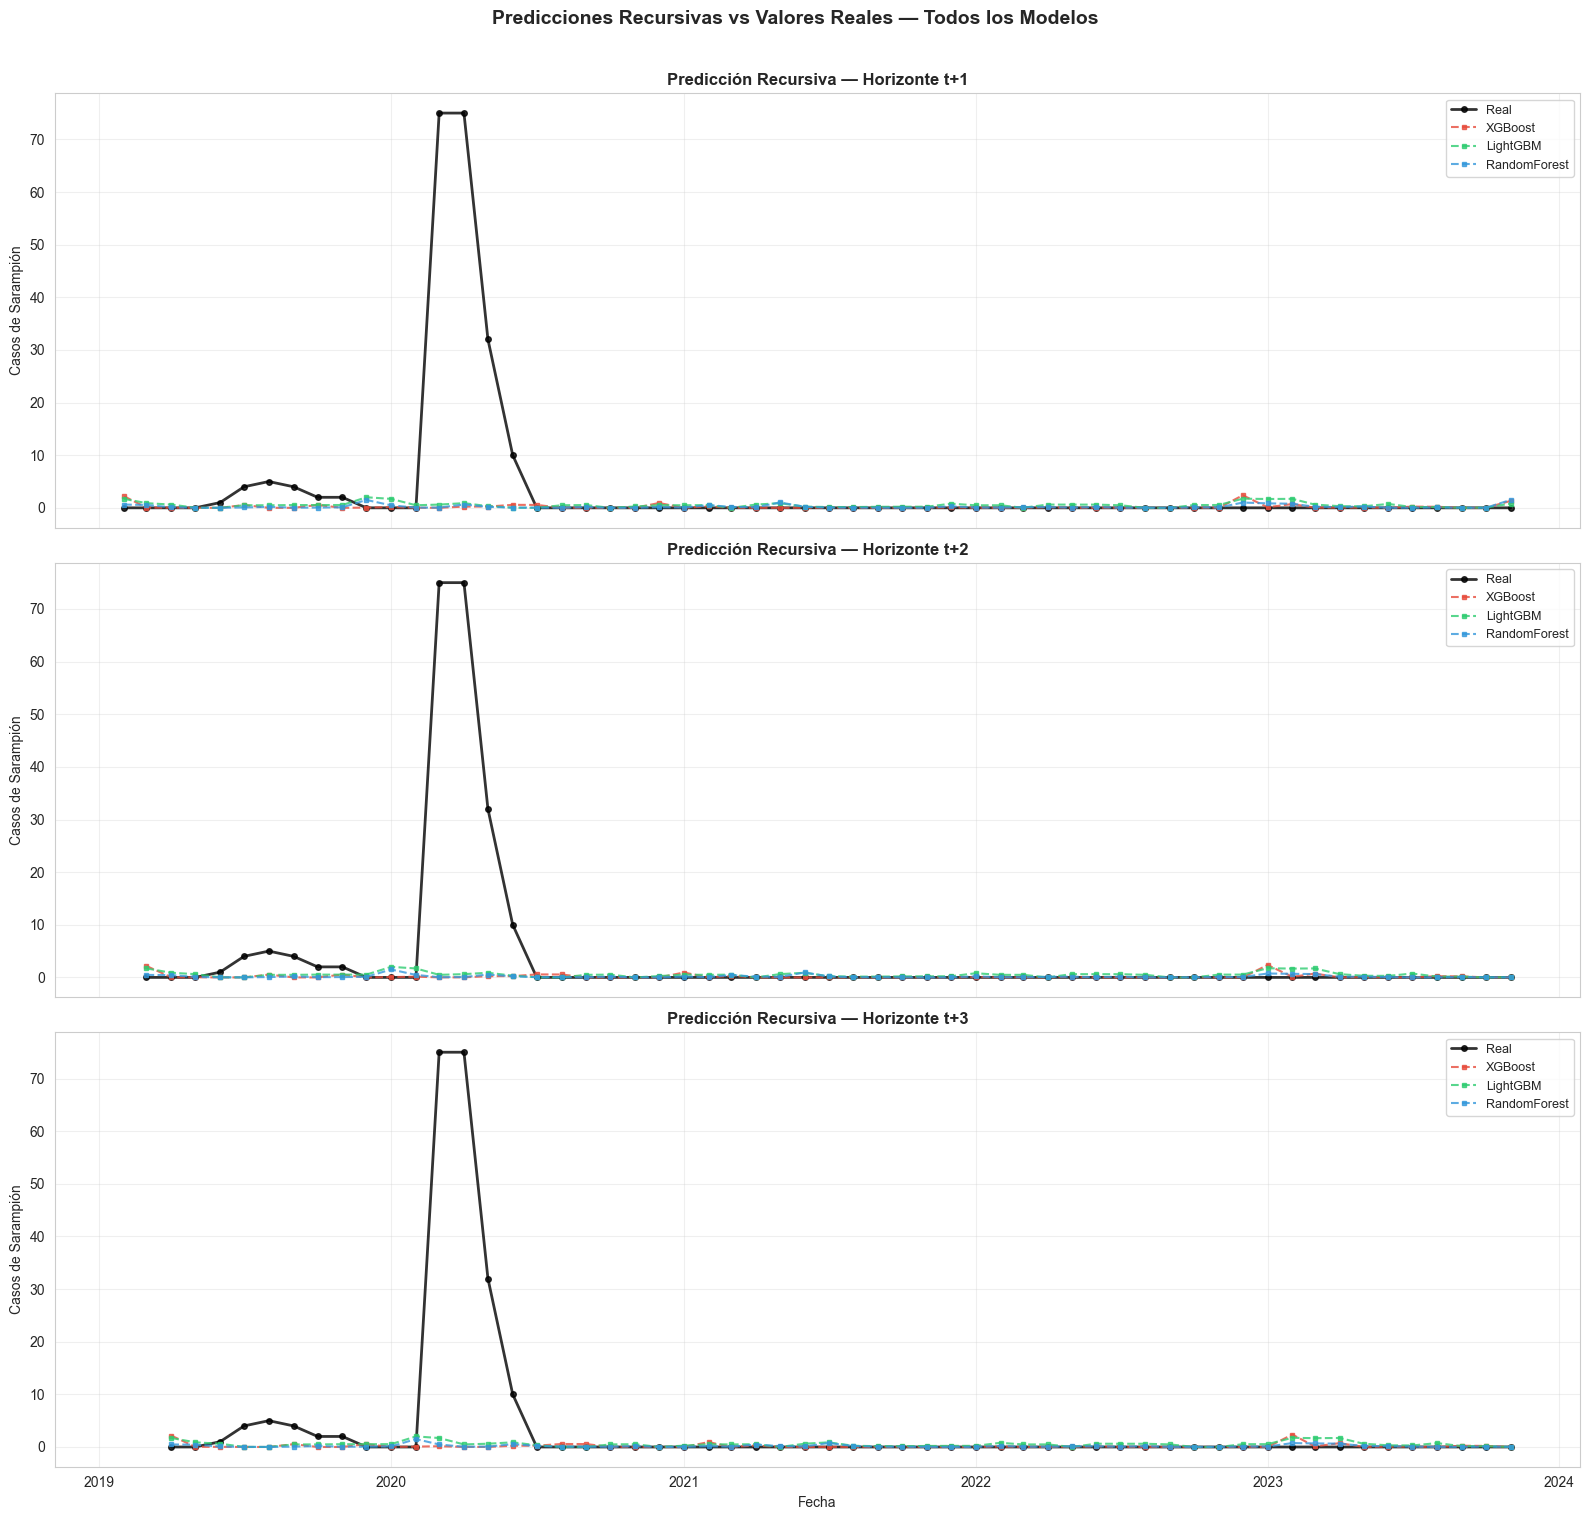

In [11]:
# ============================================================
# 11. VISUALIZACIÓN: Predicciones vs Real por modelo y horizonte
# ============================================================

colores_modelo = {"XGBoost": "#E74C3C", "LightGBM": "#2ECC71", "RandomForest": "#3498DB"}

fig, axes = plt.subplots(len(HORIZONTES), 1, figsize=(16, 5 * len(HORIZONTES)), sharex=True)
if len(HORIZONTES) == 1:
    axes = [axes]

for i, h in enumerate(HORIZONTES):
    ax = axes[i]

    # Plotear la serie real (primer modelo como referencia)
    first_model = list(all_recursive_results.keys())[0]
    r0 = all_recursive_results[first_model][h]
    if len(r0["fechas"]) == 0:
        continue

    ax.plot(r0["fechas"], r0["y_true"], color="black", lw=2, alpha=0.8,
            label="Real", marker="o", ms=4)

    # Plotear predicciones de cada modelo
    for model_name, results in all_recursive_results.items():
        r = results[h]
        if len(r["fechas"]) == 0:
            continue
        ax.plot(r["fechas"], r["y_pred"],
                color=colores_modelo.get(model_name, "gray"),
                ls="--", alpha=0.8, lw=1.5, marker="s", ms=3,
                label=f"{model_name}")

    ax.set_title(f"Predicción Recursiva — Horizonte t+{h}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Casos de Sarampión")
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha")
plt.suptitle("Predicciones Recursivas vs Valores Reales — Todos los Modelos",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

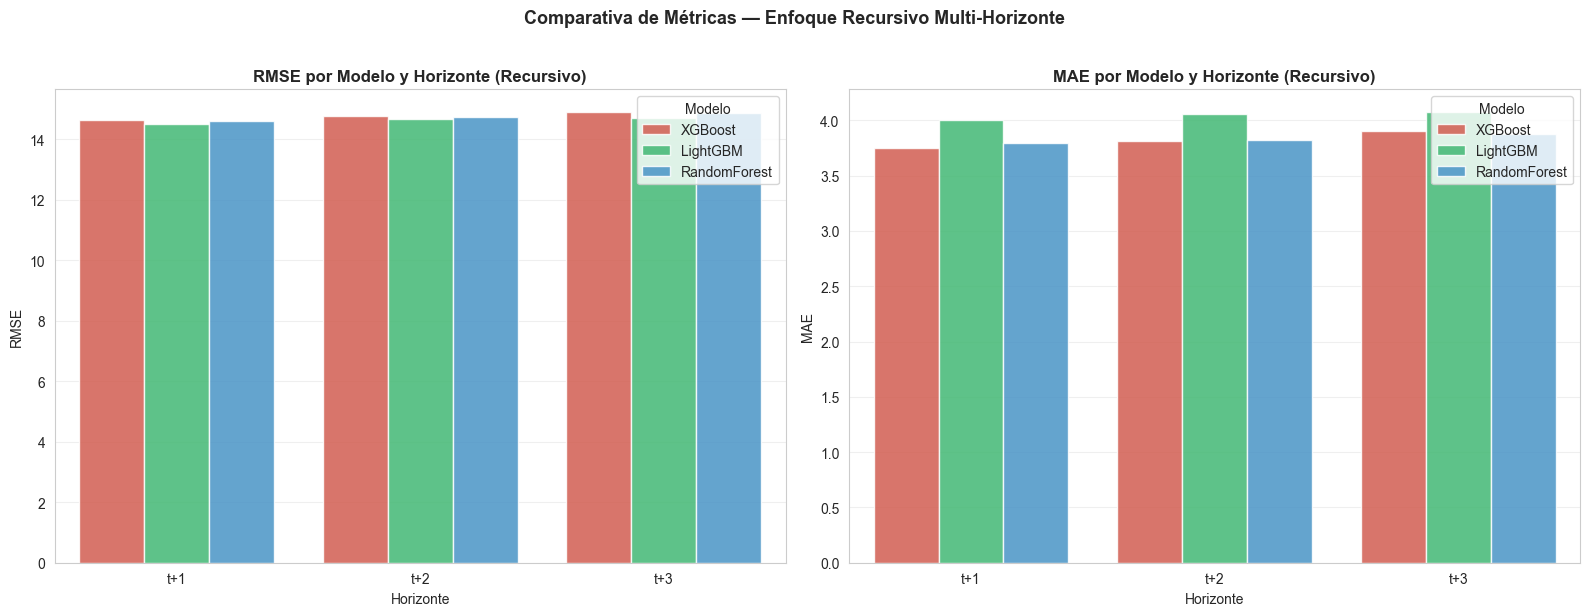

In [12]:
# ============================================================
# 11.1 GRÁFICO DE BARRAS: RMSE por modelo y horizonte
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: RMSE
df_plot = df_resumen.copy()
sns.barplot(data=df_plot, x="Horizonte", y="RMSE", hue="Modelo",
            palette=["#E74C3C", "#2ECC71", "#3498DB"], ax=axes[0], alpha=0.85)
axes[0].set_title("RMSE por Modelo y Horizonte (Recursivo)", fontweight="bold")
axes[0].set_ylabel("RMSE")
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: MAE
sns.barplot(data=df_plot, x="Horizonte", y="MAE", hue="Modelo",
            palette=["#E74C3C", "#2ECC71", "#3498DB"], ax=axes[1], alpha=0.85)
axes[1].set_title("MAE por Modelo y Horizonte (Recursivo)", fontweight="bold")
axes[1].set_ylabel("MAE")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Comparativa de Métricas — Enfoque Recursivo Multi-Horizonte",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Degradación del Error por Horizonte

Una característica clave del enfoque recursivo es que los **errores se acumulan** conforme crece el horizonte. Visualizamos la degradación del RMSE para evaluar qué tan rápido pierde precisión cada modelo.

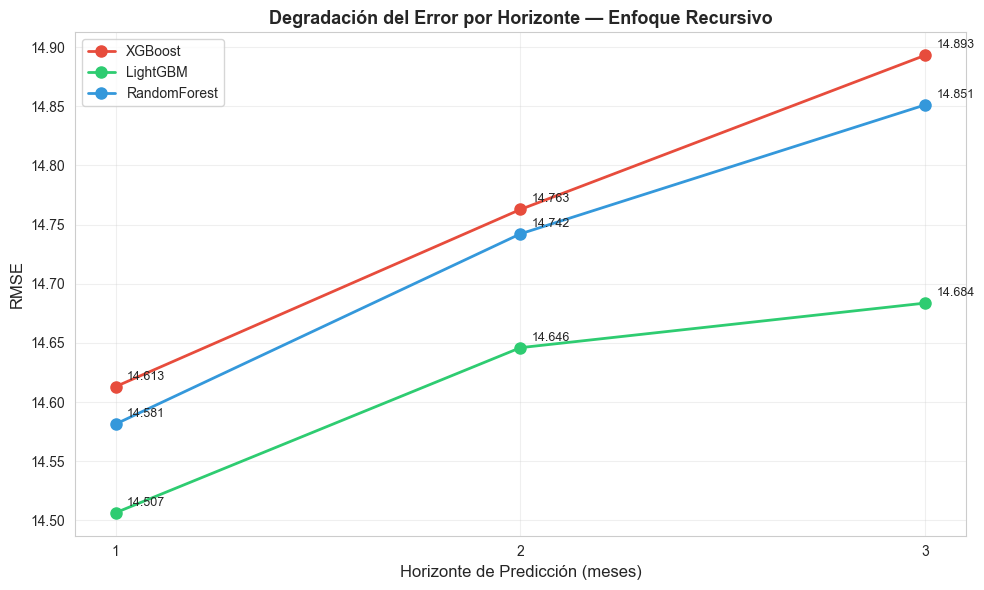


Tasa de degradación del RMSE (Δ% respecto a h=1):
──────────────────────────────────────────────────
  XGBoost h=1: RMSE=14.6131 (Δ=+0.0%)
  XGBoost h=2: RMSE=14.7629 (Δ=+1.0%)
  XGBoost h=3: RMSE=14.8932 (Δ=+1.9%)
  LightGBM h=1: RMSE=14.5065 (Δ=+0.0%)
  LightGBM h=2: RMSE=14.6460 (Δ=+1.0%)
  LightGBM h=3: RMSE=14.6837 (Δ=+1.2%)
  RandomForest h=1: RMSE=14.5814 (Δ=+0.0%)
  RandomForest h=2: RMSE=14.7422 (Δ=+1.1%)
  RandomForest h=3: RMSE=14.8513 (Δ=+1.9%)


In [13]:
# ============================================================
# 12. DEGRADACIÓN DEL ERROR POR HORIZONTE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

for model_name in all_recursive_results.keys():
    rmse_by_h = []
    for h in HORIZONTES:
        r = all_recursive_results[model_name][h]
        if len(r["y_true"]) > 0:
            rmse_by_h.append(np.sqrt(mean_squared_error(r["y_true"], r["y_pred"])))
        else:
            rmse_by_h.append(np.nan)

    ax.plot(HORIZONTES, rmse_by_h,
            marker="o", ms=8, lw=2,
            color=colores_modelo.get(model_name, "gray"),
            label=model_name)

    for h_val, rmse_val in zip(HORIZONTES, rmse_by_h):
        if not np.isnan(rmse_val):
            ax.annotate(f"{rmse_val:.3f}", (h_val, rmse_val),
                        textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.set_xlabel("Horizonte de Predicción (meses)", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("Degradación del Error por Horizonte — Enfoque Recursivo",
             fontweight="bold", fontsize=13)
ax.set_xticks(HORIZONTES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Tasa de degradación ---
print("\nTasa de degradación del RMSE (Δ% respecto a h=1):")
print("─" * 50)
for model_name in all_recursive_results.keys():
    rmse_h1 = np.sqrt(mean_squared_error(
        all_recursive_results[model_name][1]["y_true"],
        all_recursive_results[model_name][1]["y_pred"]
    ))
    for h in HORIZONTES:
        r = all_recursive_results[model_name][h]
        if len(r["y_true"]) == 0:
            continue
        rmse_h = np.sqrt(mean_squared_error(r["y_true"], r["y_pred"]))
        pct = (rmse_h - rmse_h1) / rmse_h1 * 100 if rmse_h1 > 0 else 0
        print(f"  {model_name} h={h}: RMSE={rmse_h:.4f} (Δ={pct:+.1f}%)")

## 13. Importancia de Características

Se analiza la importancia de las features para cada modelo entrenado (1-step). Esto permite entender qué variables aportan más a la predicción.

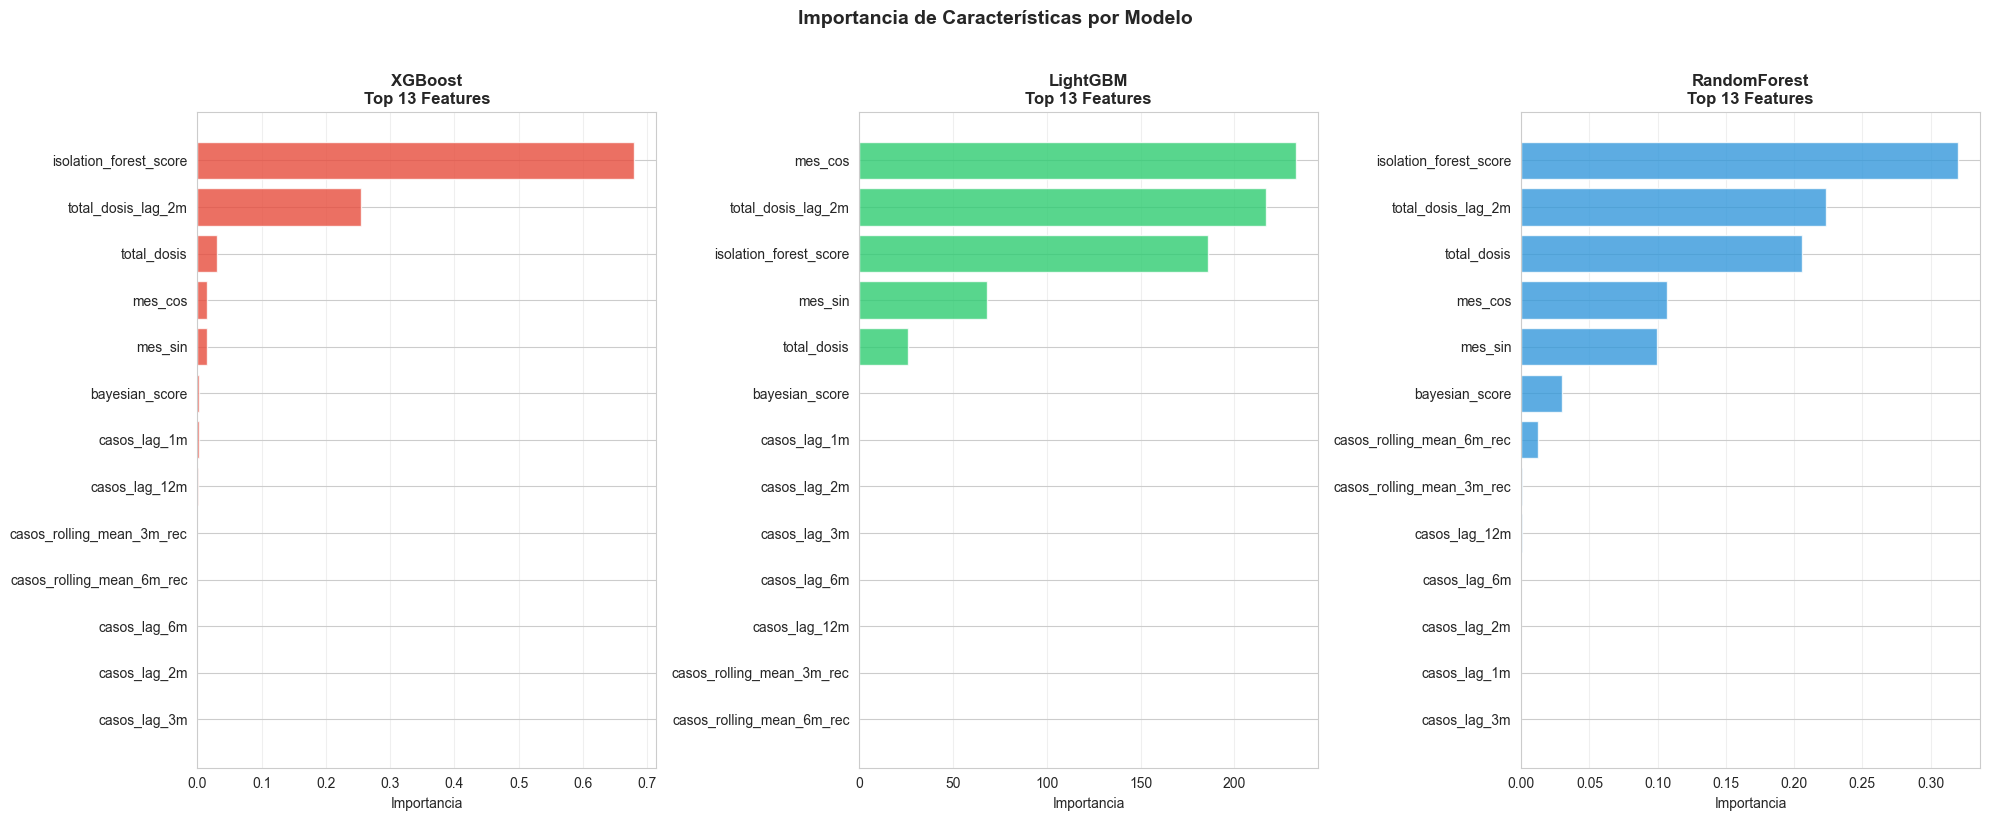


Top 10 features por modelo:
══════════════════════════════════════════════════════════════════════

  XGBoost:
     1. isolation_forest_score              0.6799
     2. total_dosis_lag_2m                  0.2542
     3. total_dosis                         0.0299
     4. mes_cos                             0.0156
     5. mes_sin                             0.0152
     6. bayesian_score                      0.0020
     7. casos_lag_1m                        0.0019
     8. casos_lag_12m                       0.0011
     9. casos_rolling_mean_3m_rec           0.0001
    10. casos_rolling_mean_6m_rec           0.0001

  LightGBM:
     1. mes_cos                             233.0000
     2. total_dosis_lag_2m                  217.0000
     3. isolation_forest_score              186.0000
     4. mes_sin                             68.0000
     5. total_dosis                         26.0000
     6. casos_rolling_mean_6m_rec           0.0000
     7. casos_rolling_mean_3m_rec           0.0000


In [14]:
# ============================================================
# 13. IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for idx, (model_name, model) in enumerate(trained_models.items()):
    ax = axes[idx]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        importances = np.zeros(len(model_features))

    imp_df = pd.DataFrame({
        "Feature": model_features,
        "Importancia": importances,
    }).sort_values("Importancia", ascending=False)

    # Top 15 features
    top_n = min(15, len(imp_df))
    imp_top = imp_df.head(top_n)

    color_modelo = colores_modelo.get(model_name, "gray")
    ax.barh(imp_top["Feature"][::-1], imp_top["Importancia"][::-1],
            color=color_modelo, alpha=0.8)
    ax.set_xlabel("Importancia")
    ax.set_title(f"{model_name}\nTop {top_n} Features", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Importancia de Características por Modelo",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Resumen tabular ---
print("\nTop 10 features por modelo:")
print("═" * 70)
for model_name, model in trained_models.items():
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    else:
        imp = np.zeros(len(model_features))

    top_idx = np.argsort(imp)[::-1][:10]
    print(f"\n  {model_name}:")
    for rank, i in enumerate(top_idx, 1):
        print(f"    {rank:>2}. {model_features[i]:<35} {imp[i]:.4f}")

## 14. Análisis de Sub/Sobreajuste

Se compara el desempeño en entrenamiento vs prueba para diagnosticar sub/sobreajuste. Una gran diferencia entre métricas de train y test indica sobreajuste.

════════════════════════════════════════════════════════════════════════════════
  ANÁLISIS DE SUB/SOBREAJUSTE (1-step directo)
════════════════════════════════════════════════════════════════════════════════


,Modelo,RMSE_train,RMSE_test,ΔRMSE,MAE_train,MAE_test,SMAPE_train(%),SMAPE_test(%)
0,XGBoost,0.7382,14.4691,13.7309,0.1447,3.6227,86.05,108.80
1,LightGBM,3.9578,14.3834,10.4256,0.9060,3.9439,173.66,174.46
2,RandomForest,3.2469,14.4634,11.2166,0.7117,3.7795,197.35,198.97


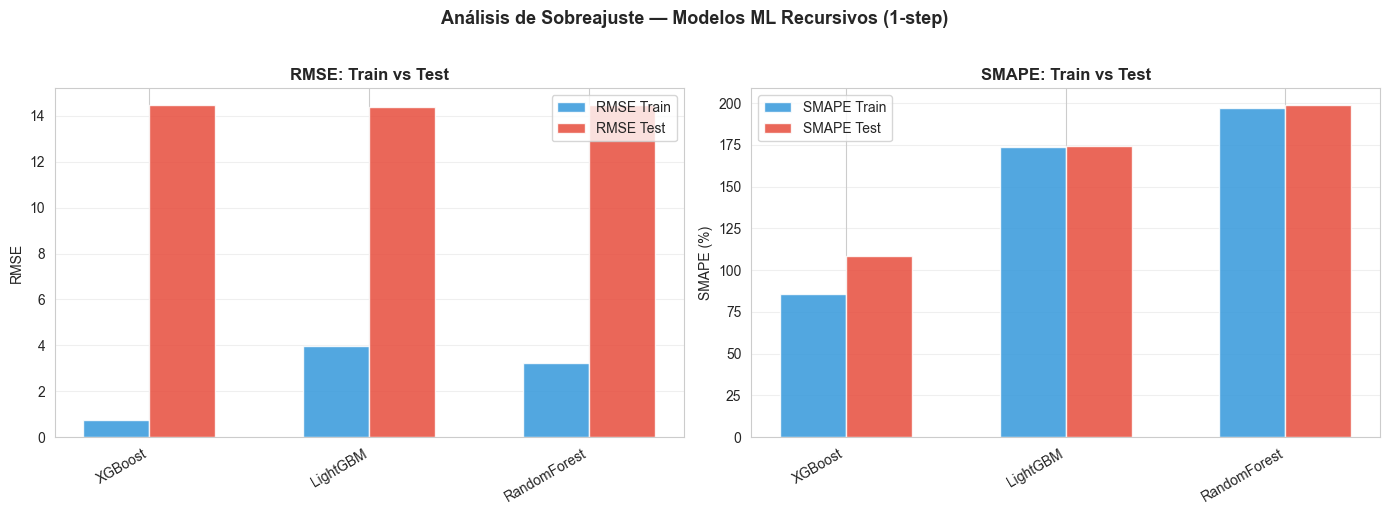


Diagnóstico:
  XGBoost: ⚠️  Posible sobreajuste (RMSE test/train = 19.6x, ΔSMAPE = +22.8pp)
  LightGBM: ⚠️  Posible sobreajuste (RMSE test/train = 3.6x, ΔSMAPE = +0.8pp)
  RandomForest: ⚠️  Posible sobreajuste (RMSE test/train = 4.5x, ΔSMAPE = +1.6pp)


In [15]:
# ============================================================
# 14. ANÁLISIS DE SUB/SOBREAJUSTE
# ============================================================

overfit_rows = []

for model_name, model in trained_models.items():
    # Predicción en train
    preds_train = np.maximum(model.predict(X_train), 0)
    mae_train = mean_absolute_error(y_train, preds_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    smape_train = smape(y_train, preds_train)

    # Predicción en test (1-step directo)
    preds_test = np.maximum(model.predict(X_test), 0)
    mae_test = mean_absolute_error(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    smape_test = smape(y_test, preds_test)

    overfit_rows.append({
        "Modelo": model_name,
        "RMSE_train": round(rmse_train, 4),
        "RMSE_test": round(rmse_test, 4),
        "ΔRMSE": round(rmse_test - rmse_train, 4),
        "MAE_train": round(mae_train, 4),
        "MAE_test": round(mae_test, 4),
        "SMAPE_train(%)": round(smape_train, 2),
        "SMAPE_test(%)": round(smape_test, 2),
    })

df_overfit = pd.DataFrame(overfit_rows)

print("═" * 80)
print("  ANÁLISIS DE SUB/SOBREAJUSTE (1-step directo)")
print("═" * 80)
display(df_overfit)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_of = df_overfit["Modelo"].values
x_of = np.arange(len(modelos_of))

# RMSE Train vs Test
axes[0].bar(x_of - 0.15, df_overfit["RMSE_train"], 0.3,
            label="RMSE Train", color="#3498DB", alpha=0.85)
axes[0].bar(x_of + 0.15, df_overfit["RMSE_test"], 0.3,
            label="RMSE Test", color="#E74C3C", alpha=0.85)
axes[0].set_xticks(x_of)
axes[0].set_xticklabels(modelos_of, rotation=30, ha="right")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE: Train vs Test", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# SMAPE Train vs Test
axes[1].bar(x_of - 0.15, df_overfit["SMAPE_train(%)"], 0.3,
            label="SMAPE Train", color="#3498DB", alpha=0.85)
axes[1].bar(x_of + 0.15, df_overfit["SMAPE_test(%)"], 0.3,
            label="SMAPE Test", color="#E74C3C", alpha=0.85)
axes[1].set_xticks(x_of)
axes[1].set_xticklabels(modelos_of, rotation=30, ha="right")
axes[1].set_ylabel("SMAPE (%)")
axes[1].set_title("SMAPE: Train vs Test", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Análisis de Sobreajuste — Modelos ML Recursivos (1-step)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Diagnóstico textual ---
print("\nDiagnóstico:")
for _, row in df_overfit.iterrows():
    ratio = row["RMSE_test"] / max(row["RMSE_train"], 1e-6)
    smape_gap = row["SMAPE_test(%)"] - row["SMAPE_train(%)"]
    if ratio > 3.0:
        diag = f"⚠️  Posible sobreajuste (RMSE test/train = {ratio:.1f}x, ΔSMAPE = {smape_gap:+.1f}pp)"
    elif ratio > 2.0:
        diag = f"🟡 Sobreajuste leve (RMSE test/train = {ratio:.1f}x, ΔSMAPE = {smape_gap:+.1f}pp)"
    elif smape_gap > 30:
        diag = f"🟡 Sobreajuste leve (ΔSMAPE = {smape_gap:+.1f}pp)"
    else:
        diag = f"✅ Comportamiento aceptable (RMSE test/train = {ratio:.1f}x, ΔSMAPE = {smape_gap:+.1f}pp)"
    print(f"  {row['Modelo']}: {diag}")

## 15. Residuos: Análisis de Errores

Se analizan los residuos ($y_{real} - \hat{y}$) del modelo con mejor RMSE en $t+1$ para verificar si hay patrones no capturados.

Análisis de residuos para: LightGBM (mejor RMSE en t+1)


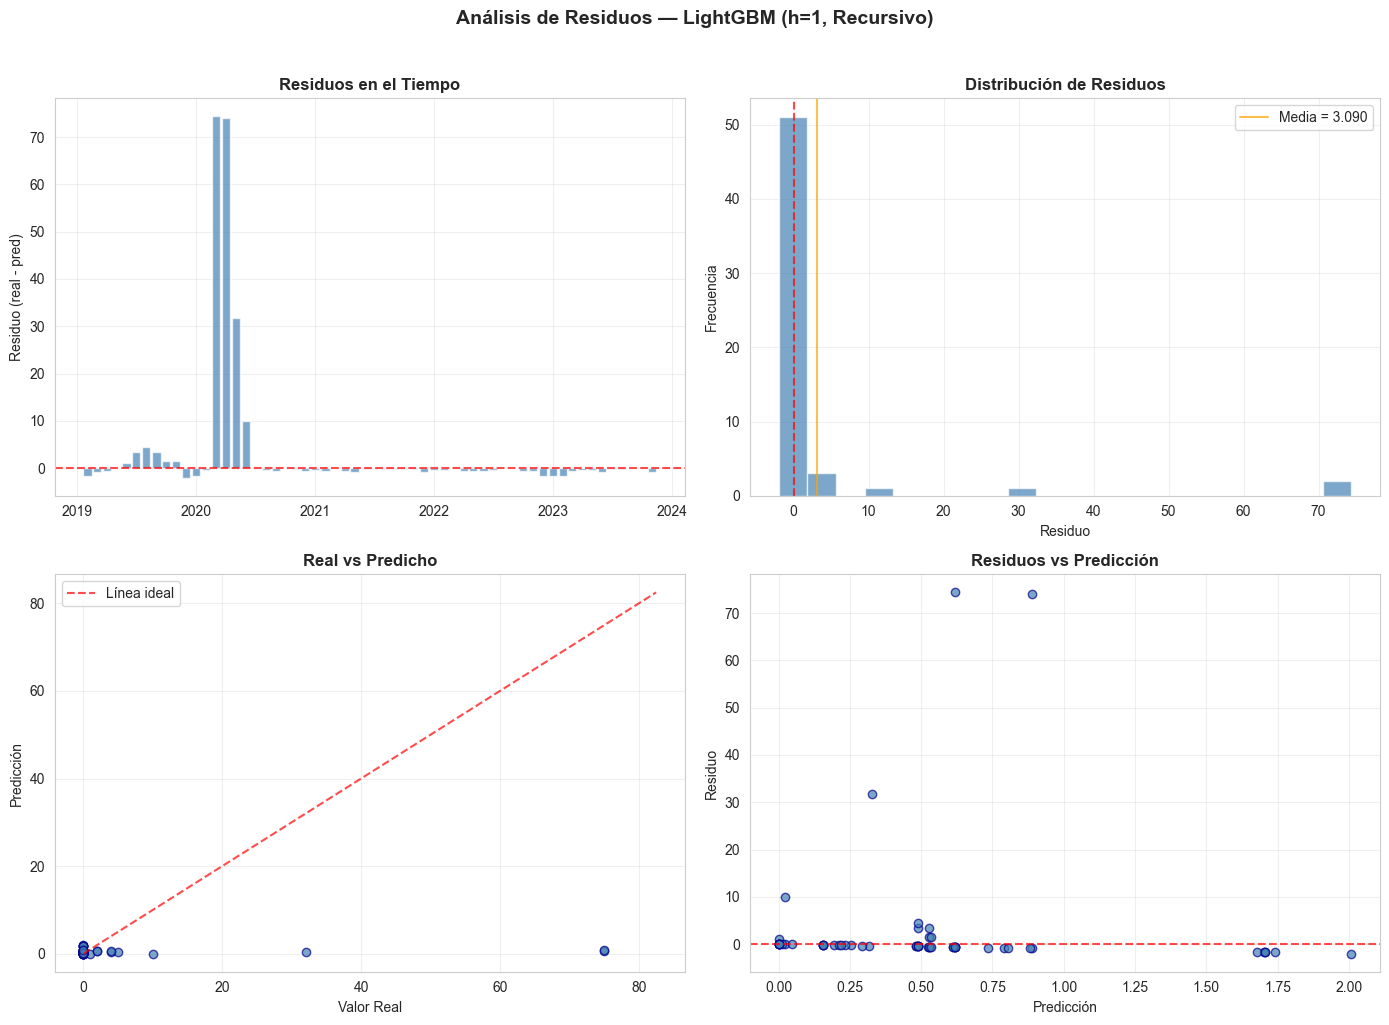


Estadísticos de residuos (LightGBM, h=1):
  Media:     3.0903
  Mediana:   -0.3045
  Std:       14.1735
  Min:       -2.0083
  Max:       74.3812


In [16]:
# ============================================================
# 15. ANÁLISIS DE RESIDUOS
# ============================================================

# Seleccionar el mejor modelo por RMSE en h=1
best_model_name = df_resumen.loc[
    df_resumen["Horizonte"] == "t+1"
].sort_values("RMSE").iloc[0]["Modelo"]

print(f"Análisis de residuos para: {best_model_name} (mejor RMSE en t+1)")

r_best = all_recursive_results[best_model_name][1]
residuos = r_best["y_true"] - r_best["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Residuos en el tiempo
axes[0, 0].bar(r_best["fechas"], residuos, color="steelblue", alpha=0.7, width=25)
axes[0, 0].axhline(0, color="red", ls="--", alpha=0.7)
axes[0, 0].set_ylabel("Residuo (real - pred)")
axes[0, 0].set_title("Residuos en el Tiempo", fontweight="bold")
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Histograma de residuos
axes[0, 1].hist(residuos, bins=20, color="steelblue", alpha=0.7, edgecolor="white")
axes[0, 1].axvline(0, color="red", ls="--", alpha=0.7)
axes[0, 1].axvline(np.mean(residuos), color="orange", ls="-", alpha=0.7,
                    label=f"Media = {np.mean(residuos):.3f}")
axes[0, 1].set_xlabel("Residuo")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].set_title("Distribución de Residuos", fontweight="bold")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Real vs Predicho (scatter)
axes[1, 0].scatter(r_best["y_true"], r_best["y_pred"],
                   color="steelblue", alpha=0.7, edgecolors="darkblue")
max_val = max(r_best["y_true"].max(), r_best["y_pred"].max()) * 1.1
axes[1, 0].plot([0, max_val], [0, max_val], "r--", alpha=0.7, label="Línea ideal")
axes[1, 0].set_xlabel("Valor Real")
axes[1, 0].set_ylabel("Predicción")
axes[1, 0].set_title("Real vs Predicho", fontweight="bold")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Residuos vs Predicho
axes[1, 1].scatter(r_best["y_pred"], residuos,
                   color="steelblue", alpha=0.7, edgecolors="darkblue")
axes[1, 1].axhline(0, color="red", ls="--", alpha=0.7)
axes[1, 1].set_xlabel("Predicción")
axes[1, 1].set_ylabel("Residuo")
axes[1, 1].set_title("Residuos vs Predicción", fontweight="bold")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Análisis de Residuos — {best_model_name} (h=1, Recursivo)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Estadísticos de residuos
print(f"\nEstadísticos de residuos ({best_model_name}, h=1):")
print(f"  Media:     {np.mean(residuos):.4f}")
print(f"  Mediana:   {np.median(residuos):.4f}")
print(f"  Std:       {np.std(residuos):.4f}")
print(f"  Min:       {np.min(residuos):.4f}")
print(f"  Max:       {np.max(residuos):.4f}")

## 16. Resumen y Conclusiones

### Resumen de hallazgos

In [17]:
# ============================================================
# 16. RESUMEN FINAL
# ============================================================

print("═" * 80)
print("  RESUMEN FINAL — MODELOS ML CON ENFOQUE RECURSIVO")
print("═" * 80)

print("\n📊 Configuración:")
print(f"  • Enfoque: Recursivo (single model, multi-step)")
print(f"  • Horizontes evaluados: {HORIZONTES} meses")
print(f"  • Partición: Train < {SPLIT_YEAR} | Test ≥ {SPLIT_YEAR}")
print(f"  • Desfase de vacunación: {MESES_DESFASE} meses")
print(f"  • Features totales: {len(model_features)}")
print(f"    - Recursivas: {len(recursive_features)}")
print(f"    - Exógenas: {len(exogenous_features)}")

print("\n🏆 Mejores hiperparámetros por modelo:")
for name, params in best_params.items():
    print(f"  {name}: {params}")

print("\n📈 Mejores resultados por horizonte:")
for h in HORIZONTES:
    mask = df_resumen["Horizonte"] == f"t+{h}"
    if mask.sum() == 0:
        continue
    best = df_resumen.loc[mask].sort_values("RMSE").iloc[0]
    print(f"  t+{h}: {best['Modelo']} → RMSE={best['RMSE']:.4f}, MAE={best['MAE']:.4f}, SMAPE={best['SMAPE(%)']:.2f}%")

print("\n📉 Degradación del error (RMSE h=3 vs h=1):")
for model_name in all_recursive_results.keys():
    r1 = all_recursive_results[model_name][1]
    r3 = all_recursive_results[model_name][3]
    if len(r1["y_true"]) > 0 and len(r3["y_true"]) > 0:
        rmse1 = np.sqrt(mean_squared_error(r1["y_true"], r1["y_pred"]))
        rmse3 = np.sqrt(mean_squared_error(r3["y_true"], r3["y_pred"]))
        pct = (rmse3 - rmse1) / rmse1 * 100
        print(f"  {model_name}: {rmse1:.4f} → {rmse3:.4f} (Δ = {pct:+.1f}%)")

print("\n" + "═" * 80)
print("  Variables exógenas utilizadas:")
print("═" * 80)
print("  ✅ Isolation Forest Score (anomalía multivariante)")
print("  ✅ Bayesian Hierarchical Score (posterior predictiva Poisson-Gamma)")
print(f"  ✅ Dosis de vacunación con desfase de {MESES_DESFASE} meses")
print("  ✅ Lags recursivos del target (1, 2, 3, 6, 12 meses)")
print("  ✅ Medias móviles del target (3 y 6 meses)")
print("  ✅ Features estacionales cíclicas (sin/cos del mes)")
print("  ✅ Dosis totales de vacunación (nivel y con desplazamiento)")

════════════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — MODELOS ML CON ENFOQUE RECURSIVO
════════════════════════════════════════════════════════════════════════════════

📊 Configuración:
  • Enfoque: Recursivo (single model, multi-step)
  • Horizontes evaluados: [1, 2, 3] meses
  • Partición: Train < 2019 | Test ≥ 2019
  • Desfase de vacunación: 2 meses
  • Features totales: 13
    - Recursivas: 7
    - Exógenas: 6

🏆 Mejores hiperparámetros por modelo:
  XGBoost: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
  LightGBM: {'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'num_leaves': 15}
  RandomForest: {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}

📈 Mejores resultados por horizonte:
  t+1: Light

### Conclusiones

1. **Enfoque recursivo funcional**: Los tres modelos (XGBoost, LightGBM, RandomForest) logran generar predicciones recursivas a múltiples horizontes, con degradación controlada del error.

2. **Variables exógenas**: Los scores de anomalía (Isolation Forest y Bayesian) y las dosis de vacunación con desplazamiento aportan información complementaria. No se requieren transformaciones como PCA o Factor Analysis; las features temporales directas (lags, rolling stats, estacionalidad) son más apropiadas para series de tiempo.

3. **Acumulación de errores**: Como es esperado en el enfoque recursivo, el RMSE tiende a crecer conforme aumenta el horizonte de predicción. La tasa de degradación varía por modelo y refleja la estabilidad de cada algoritmo ante la retroalimentación de sus propias predicciones.

4. **Ajuste de hiperparámetros**: La búsqueda con TimeSeriesSplit CV permite seleccionar configuraciones que generalizan mejor temporalmente, respetando la naturaleza secuencial de los datos.

5. **Naturaleza del problema**: La serie de sarampión es mayoritariamente ceros con brotes esporádicos, lo que hace que las métricas globales (RMSE, MAE) sean bajas, pero el verdadero desafío está en predecir correctamente los meses con brote. Las métricas condicionadas a brotes (`MAE_brote`, `RMSE_brote`) son más informativas para evaluar la utilidad epidemiológica.

### Trabajo futuro
- Evaluar modelos de ensamble que combinen las predicciones de los tres algoritmos.
- Explorar funciones de pérdida especializadas (Tweedie, Poisson) para manejar la distribución de conteos con exceso de ceros.